# Credit Card Approval Prediction
## Data Preprocessing & Model Building

This notebook performs:
- Data preprocessing
- Feature engineering
- Machine learning model building
- Model evaluation
- Best model selection

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
application = pd.read_csv("../dataset/application_record.csv")
credit = pd.read_csv("../dataset/credit_record.csv")

print("Application Dataset:", application.shape)
print("Credit Dataset:", credit.shape)

Application Dataset: (438557, 18)
Credit Dataset: (1048575, 3)


# Step 1: Create Target Variable

The credit record dataset contains multiple payment status values for each customer. Since our objective is binary classification (Approved/Rejected), we convert these payment statuses into a binary target variable.

Target Labels:
- 0 → Low Risk (Approved)
- 1 → High Risk (Rejected)

A customer is classified as High Risk if they have at least one payment status of 2, 3, 4, or 5.

In [3]:
# Create Binary Target Variable

bad_status = ['2', '3', '4', '5']

credit['TARGET'] = credit['STATUS'].apply(
    lambda x: 1 if x in bad_status else 0
)

credit.head()

,ID,MONTHS_BALANCE,STATUS,TARGET
0,5001711,0,X,0
1,5001711,-1,0,0
2,5001711,-2,0,0
3,5001711,-3,0,0
4,5001712,0,C,0


# Step 2: Aggregate Customer Credit History

Each customer has multiple monthly credit records.

We group the records by customer ID and assign the highest TARGET value.

If any record indicates bad credit history, the customer is classified as High Risk.

In [5]:
target = credit.groupby('ID')['TARGET'].max().reset_index()

print("Total Customers :", len(target))

target.head()

Total Customers : 45985


,ID,TARGET
0,5001711,0
1,5001712,0
2,5001713,0
3,5001714,0
4,5001715,0


# Step 3: Merge Application and Credit Datasets

The application dataset contains customer information, while the credit dataset contains repayment history.

Both datasets are merged using the customer ID.

In [6]:
df = application.merge(target, on='ID', how='inner')

print("Merged Dataset Shape :", df.shape)

df.head()

Merged Dataset Shape : (36457, 19)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0


# Step 4: Check Class Distribution

This helps us understand whether the dataset is balanced or imbalanced.

In [7]:
print(df['TARGET'].value_counts())

TARGET
0    35841
1      616
Name: count, dtype: int64


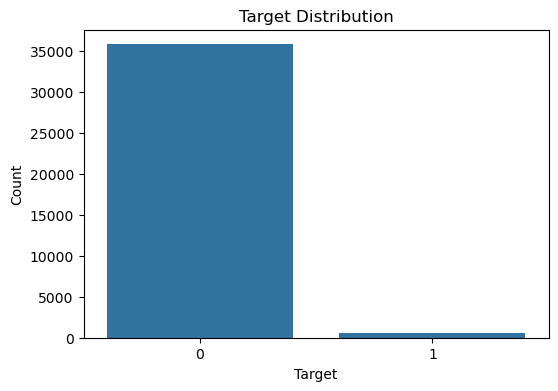

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x='TARGET', data=df)

plt.title("Target Distribution")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

# Step 5: Handle Missing Values

The Occupation Type column contains missing values.

We replace missing values with "Unknown" to preserve all records.

In [9]:
df.isnull().sum()

ID                         0
CODE_GENDER                0
FLAG_OWN_CAR               0
FLAG_OWN_REALTY            0
CNT_CHILDREN               0
AMT_INCOME_TOTAL           0
NAME_INCOME_TYPE           0
NAME_EDUCATION_TYPE        0
NAME_FAMILY_STATUS         0
NAME_HOUSING_TYPE          0
DAYS_BIRTH                 0
DAYS_EMPLOYED              0
FLAG_MOBIL                 0
FLAG_WORK_PHONE            0
FLAG_PHONE                 0
FLAG_EMAIL                 0
OCCUPATION_TYPE        11323
CNT_FAM_MEMBERS            0
TARGET                     0
dtype: int64

In [10]:
df['OCCUPATION_TYPE'] = df['OCCUPATION_TYPE'].fillna('Unknown')

In [11]:
df.isnull().sum()

ID                     0
CODE_GENDER            0
FLAG_OWN_CAR           0
FLAG_OWN_REALTY        0
CNT_CHILDREN           0
AMT_INCOME_TOTAL       0
NAME_INCOME_TYPE       0
NAME_EDUCATION_TYPE    0
NAME_FAMILY_STATUS     0
NAME_HOUSING_TYPE      0
DAYS_BIRTH             0
DAYS_EMPLOYED          0
FLAG_MOBIL             0
FLAG_WORK_PHONE        0
FLAG_PHONE             0
FLAG_EMAIL             0
OCCUPATION_TYPE        0
CNT_FAM_MEMBERS        0
TARGET                 0
dtype: int64

# Step 6: Feature Engineering

Feature engineering improves the dataset by creating meaningful features from existing columns.

The following transformations are performed:

- Convert DAYS_BIRTH into AGE
- Convert DAYS_EMPLOYED into YEARS_EMPLOYED
- Handle special employment values
- Remove unnecessary columns

In [12]:
# Convert DAYS_BIRTH into AGE (Years)

df['AGE'] = (-df['DAYS_BIRTH'] / 365).astype(int)

df[['DAYS_BIRTH', 'AGE']].head()

,DAYS_BIRTH,AGE
0,-12005,32
1,-12005,32
2,-21474,58
3,-19110,52
4,-19110,52


In [13]:
# Replace special value

df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, 0)

In [14]:
# Convert days into years

df['YEARS_EMPLOYED'] = (abs(df['DAYS_EMPLOYED']) / 365).astype(int)

df[['DAYS_EMPLOYED', 'YEARS_EMPLOYED']].head()

,DAYS_EMPLOYED,YEARS_EMPLOYED
0,-4542,12
1,-4542,12
2,-1134,3
3,-3051,8
4,-3051,8


In [15]:
# Drop columns not needed for training

df.drop(
    columns=[
        'ID',
        'DAYS_BIRTH',
        'DAYS_EMPLOYED'
    ],
    inplace=True
)

In [16]:
df.head()

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET,AGE,YEARS_EMPLOYED
0,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,Unknown,2.0,0,32,12
1,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,Unknown,2.0,0,32,12
2,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Security staff,2.0,0,58,3
3,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,0,52,8
4,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,0,52,8


# Step 7: Remove Duplicate Records

Duplicate records may negatively impact model performance. These records are removed before training.

In [17]:
print("Before Removing Duplicates :", df.shape)

df = df.drop_duplicates()

print("After Removing Duplicates :", df.shape)

Before Removing Duplicates : (36457, 18)
After Removing Duplicates : (9828, 18)


# Step 8: Encode Categorical Features

Machine learning models require numerical input. Therefore, all categorical variables are converted into numerical values using Label Encoding.

In [18]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_columns = df.select_dtypes(include='object').columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE',
       'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
       'OCCUPATION_TYPE'],
      dtype='object')


In [19]:
for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

print("Encoding Completed Successfully!")

Encoding Completed Successfully!


In [20]:
df.head()

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET,AGE,YEARS_EMPLOYED
0,1,1,1,0,427500.0,4,1,0,4,1,1,0,0,17,2.0,0,32,12
2,1,1,1,0,112500.0,4,4,1,1,1,0,0,0,16,2.0,0,58,3
3,0,0,1,0,270000.0,0,4,3,1,1,0,1,1,14,1.0,0,52,8
7,0,0,1,0,283500.0,1,1,2,1,1,0,0,0,17,1.0,0,61,0
10,1,1,1,0,270000.0,4,1,1,1,1,1,1,1,0,2.0,0,46,2


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9828 entries, 0 to 36456
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CODE_GENDER          9828 non-null   int64  
 1   FLAG_OWN_CAR         9828 non-null   int64  
 2   FLAG_OWN_REALTY      9828 non-null   int64  
 3   CNT_CHILDREN         9828 non-null   int64  
 4   AMT_INCOME_TOTAL     9828 non-null   float64
 5   NAME_INCOME_TYPE     9828 non-null   int64  
 6   NAME_EDUCATION_TYPE  9828 non-null   int64  
 7   NAME_FAMILY_STATUS   9828 non-null   int64  
 8   NAME_HOUSING_TYPE    9828 non-null   int64  
 9   FLAG_MOBIL           9828 non-null   int64  
 10  FLAG_WORK_PHONE      9828 non-null   int64  
 11  FLAG_PHONE           9828 non-null   int64  
 12  FLAG_EMAIL           9828 non-null   int64  
 13  OCCUPATION_TYPE      9828 non-null   int64  
 14  CNT_FAM_MEMBERS      9828 non-null   float64
 15  TARGET               9828 non-null   int64

# Step 9: Save Processed Dataset

The cleaned and transformed dataset is saved for future use during model training and deployment.

In [22]:
df.to_csv("../dataset/processed_credit_data.csv", index=False)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!


# Step 10: Split Dataset

The processed dataset is divided into training and testing sets.

- Training Data: 80%
- Testing Data: 20%

The machine learning models are trained using the training data and evaluated using the testing data.

In [23]:
# Features and Target

X = df.drop("TARGET", axis=1)
y = df["TARGET"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (9828, 17)
Target Shape : (9828,)


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (7862, 17)
Testing Samples : (1966, 17)


# Step 11: Feature Scaling

Feature scaling standardizes numerical values so that machine learning algorithms perform better.

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature Scaling Completed.")

Feature Scaling Completed.


# Step 12: Logistic Regression

In [26]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy :", lr_accuracy)

Logistic Regression Accuracy : 0.9552390640895219


In [27]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1878
           1       0.00      0.00      0.00        88

    accuracy                           0.96      1966
   macro avg       0.48      0.50      0.49      1966
weighted avg       0.91      0.96      0.93      1966



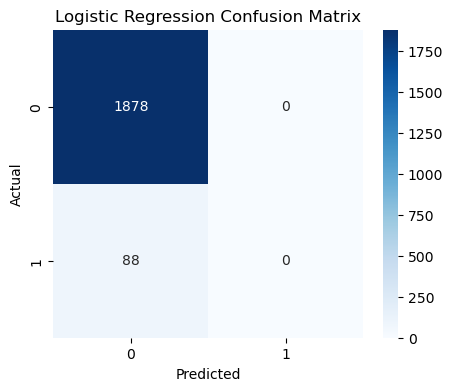

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Step 13: Decision Tree Classifier

In [29]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy :", dt_accuracy)

Decision Tree Accuracy : 0.9109867751780264


In [30]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.96      0.95      0.95      1878
           1       0.06      0.07      0.06        88

    accuracy                           0.91      1966
   macro avg       0.51      0.51      0.51      1966
weighted avg       0.92      0.91      0.91      1966



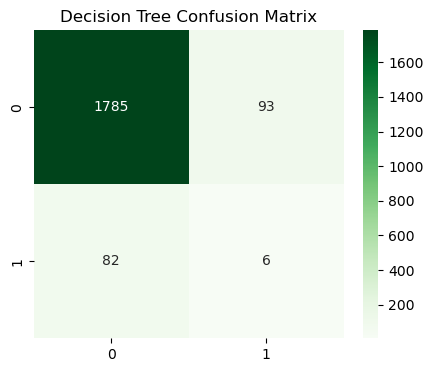

In [31]:
cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Greens')

plt.title("Decision Tree Confusion Matrix")

plt.show()

# Step 14: Random Forest Classifier

In [32]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy :", rf_accuracy)

Random Forest Accuracy : 0.9379450661241099


In [33]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.95      0.98      0.97      1878
           1       0.03      0.01      0.02        88

    accuracy                           0.94      1966
   macro avg       0.49      0.50      0.49      1966
weighted avg       0.91      0.94      0.93      1966



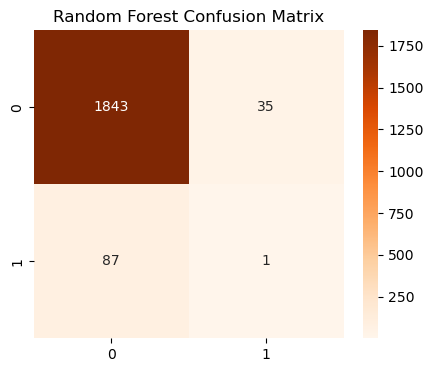

In [34]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Oranges')

plt.title("Random Forest Confusion Matrix")

plt.show()

In [35]:
import xgboost

print(xgboost.__version__)

3.3.0


# Step 15: XGBoost Classifier

XGBoost (Extreme Gradient Boosting) is an advanced ensemble learning algorithm that often provides excellent performance on structured datasets.

The model is trained and evaluated using the testing dataset.

In [36]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy :", round(xgb_accuracy * 100, 2), "%")

XGBoost Accuracy : 94.56 %


In [37]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97      1878
           1       0.12      0.03      0.05        88

    accuracy                           0.95      1966
   macro avg       0.54      0.51      0.51      1966
weighted avg       0.92      0.95      0.93      1966



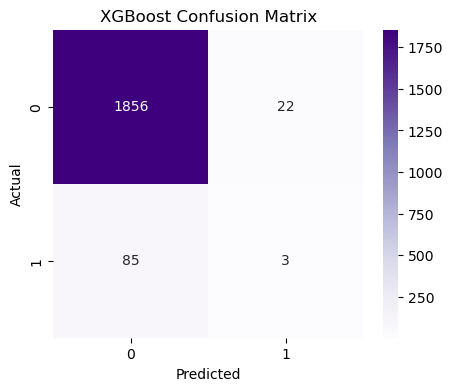

In [38]:
cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Step 16: Model Comparison

The performance of all four classification algorithms is compared using their accuracy scores.

In [39]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        xgb_accuracy
    ]
})

results["Accuracy (%)"] = results["Accuracy"] * 100

results = results.sort_values(
    by="Accuracy",
    ascending=False
)

results.reset_index(drop=True, inplace=True)

results

,Model,Accuracy,Accuracy (%)
0,Logistic Regression,0.955239,95.523906
1,XGBoost,0.945575,94.557477
2,Random Forest,0.937945,93.794507
3,Decision Tree,0.910987,91.098678


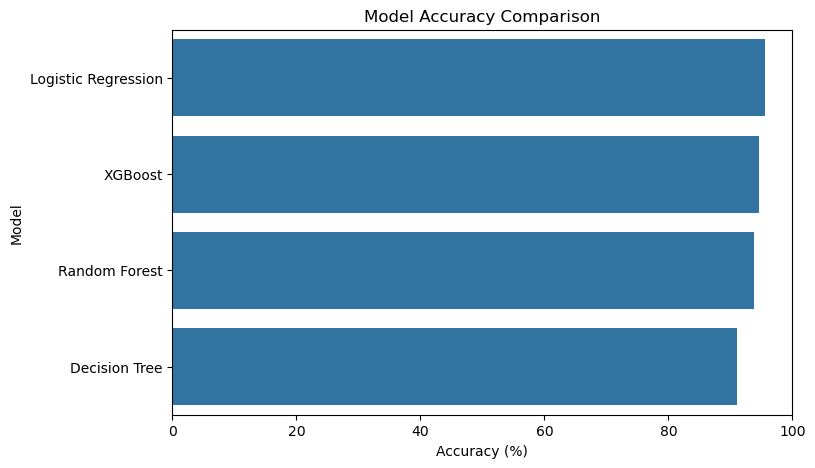

In [40]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Accuracy (%)",
    y="Model"
)

plt.title("Model Accuracy Comparison")

plt.xlim(0,100)

plt.show()

# Step 17: Select Best Model

The model with the highest accuracy is selected and saved for deployment in the Flask web application.

In [41]:
models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "XGBoost": xgb
}

best_model_name = results.iloc[0]["Model"]

best_model = models[best_model_name]

print("Best Model :", best_model_name)

print("Accuracy :", round(results.iloc[0]["Accuracy (%)"],2),"%")

Best Model : Logistic Regression
Accuracy : 95.52 %


In [42]:
import os
import joblib

os.makedirs("../model", exist_ok=True)

joblib.dump(best_model, "../model/best_model.pkl")
joblib.dump(scaler, "../model/scaler.pkl")

print("Best model saved successfully!")
print("Scaler saved successfully!")

Best model saved successfully!
Scaler saved successfully!


In [43]:
if best_model_name in ["Random Forest", "XGBoost"]:

    feature_importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_model.feature_importances_
    })

    feature_importance = feature_importance.sort_values(
        by="Importance",
        ascending=False
    )

    plt.figure(figsize=(10,6))

    sns.barplot(
        data=feature_importance.head(10),
        x="Importance",
        y="Feature"
    )

    plt.title("Top 10 Important Features")

    plt.show()

# Conclusion

Four machine learning classification algorithms were trained and evaluated:

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

The best-performing model was selected based on accuracy and saved for deployment.

This trained model will be integrated into a Flask web application to provide real-time credit card approval predictions.

# Production Ready Machine Learning Pipeline

In this section, we build a production-ready machine learning pipeline using Scikit-learn Pipeline and ColumnTransformer.

This pipeline automatically performs:

- Missing value handling
- One-Hot Encoding
- Feature Scaling
- Model Training

The trained pipeline is saved as a single file for deployment in the Flask application.

In [45]:
application = pd.read_csv("../dataset/application_record.csv")
credit = pd.read_csv("../dataset/credit_record.csv")

bad_status = ['2', '3', '4', '5']

credit['TARGET'] = credit['STATUS'].apply(
    lambda x: 1 if x in bad_status else 0
)

target = credit.groupby('ID')['TARGET'].max().reset_index()

df = application.merge(target, on='ID', how='inner')

In [46]:
df['OCCUPATION_TYPE'] = df['OCCUPATION_TYPE'].fillna("Unknown")

df['AGE'] = (-df['DAYS_BIRTH'] / 365).astype(int)

df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243,0)

df['YEARS_EMPLOYED'] = (abs(df['DAYS_EMPLOYED'])/365).astype(int)

df.drop(
    columns=[
        'ID',
        'DAYS_BIRTH',
        'DAYS_EMPLOYED'
    ],
    inplace=True
)

In [47]:
X = df.drop("TARGET", axis=1)

y = df["TARGET"]

X.head()

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,AGE,YEARS_EMPLOYED
0,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,Unknown,2.0,32,12
1,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,Unknown,2.0,32,12
2,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Security staff,2.0,58,3
3,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,52,8
4,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,52,8


In [48]:
categorical_features = X.select_dtypes(include="object").columns.tolist()

numeric_features = X.select_dtypes(exclude="object").columns.tolist()

print(categorical_features)

print(numeric_features)

['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']
['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'AGE', 'YEARS_EMPLOYED']


In [49]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [50]:
preprocessor = ColumnTransformer(

    transformers=[

        ("num",
         StandardScaler(),
         numeric_features),

        ("cat",
         OneHotEncoder(handle_unknown="ignore"),
         categorical_features)

    ]

)

In [51]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(

    n_estimators=200,

    random_state=42

)

In [52]:
pipeline = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("model", model)

    ]

)

In [53]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [54]:
prediction = pipeline.predict(X_test)

accuracy = accuracy_score(y_test,prediction)

print("Accuracy :",accuracy)

Accuracy : 0.9813494240263302


In [55]:
import joblib

joblib.dump(

    pipeline,

    "../model/credit_card_pipeline.pkl"

)

print("Pipeline Saved Successfully")

Pipeline Saved Successfully
